## Exploratory Data Analysis

#### 1. Imports and Configuration

In [ ]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path(os.getcwd())
RAW           = Path("../data/raw")
TICKETS_PATH  = RAW / "support_tickets_10k.csv"
FAQ_KNOWLEDGE_BASE_PATH = RAW / "faq_knowledge_base_150.csv"

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 11,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "#F8FAFC",
})

# Brand palette — banking blues + fraud red
BLUE    = "#2563EB"
TEAL    = "#0891B2"
GREEN   = "#16A34A"
RED     = "#DC2626"
AMBER   = "#D97706"
PURPLE  = "#7C3AED"
PALETTE = [BLUE, GREEN, RED, AMBER, PURPLE, TEAL]

def section(title: str) -> None:
    """Print a visible section divider."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print('='*60)
print("✅ Setup complete")

✅ Setup complete


#### 2. Load Data

In [2]:
tickets_df = pd.read_csv(TICKETS_PATH)
faq_df = pd.read_csv(FAQ_KNOWLEDGE_BASE_PATH)

In [5]:
tickets_df['created_date'] = pd.to_datetime(tickets_df['created_date'])
tickets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    10000 non-null  str           
 1   created_date                 10000 non-null  datetime64[us]
 2   ticket_text                  10000 non-null  str           
 3   product_name                 10000 non-null  str           
 4   product_segment              10000 non-null  str           
 5   ticket_category              10000 non-null  str           
 6   priority                     10000 non-null  str           
 7   sentiment                    10000 non-null  str           
 8   confidence_score             10000 non-null  float64       
 9   escalated                    10000 non-null  str           
 10  resolution_text              10000 non-null  str           
 11  resolved_date                10000 non-null  str     

In [6]:
faq_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   faq_id    150 non-null    str  
 1   question  150 non-null    str  
 2   answer    150 non-null    str  
 3   category  150 non-null    str  
dtypes: str(4)
memory usage: 4.8 KB


#### 3. Class Balance Check


  Category / Priority / Sentiment Distributions


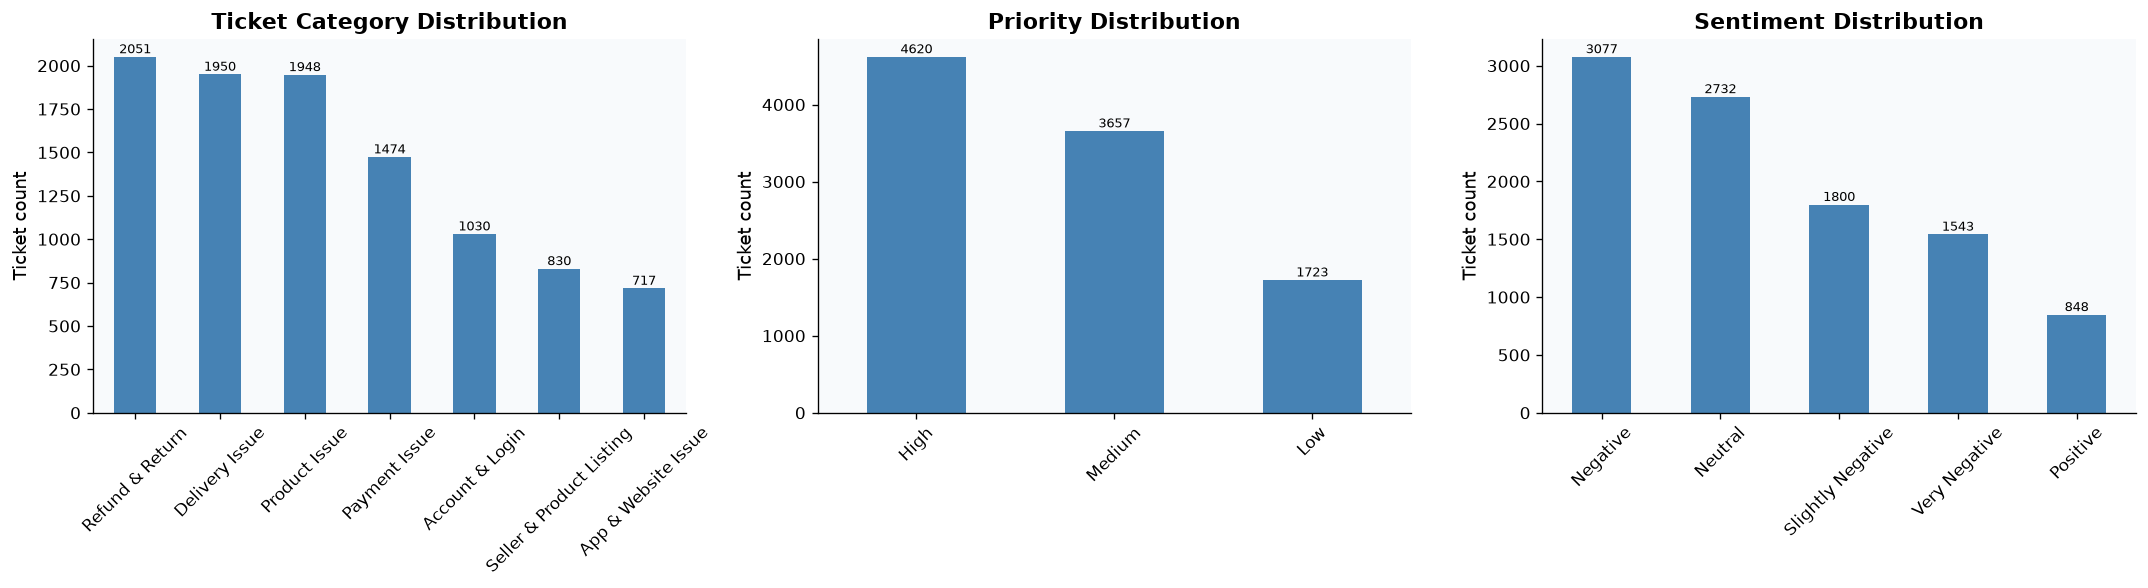

ticket_category:
 ticket_category
Refund & Return             0.205
Delivery Issue              0.195
Product Issue               0.195
Payment Issue               0.147
Account & Login             0.103
Seller & Product Listing    0.083
App & Website Issue         0.072
Name: proportion, dtype: float64 

priority:
 priority
High      0.462
Medium    0.366
Low       0.172
Name: proportion, dtype: float64 

sentiment:
 sentiment
Negative             0.308
Neutral              0.273
Slightly Negative    0.180
Very Negative        0.154
Positive             0.085
Name: proportion, dtype: float64


In [ ]:
section("Category / Priority / Sentiment Distributions")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['ticket_category', 'priority', 'sentiment'],
    ['Ticket Category', 'Priority', 'Sentiment'],
):
    counts = tickets_df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{title} Distribution')
    ax.set_xlabel('')
    ax.set_ylabel('Ticket count')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("ticket_category:\n", tickets_df['ticket_category'].value_counts(normalize=True).round(3), "\n")
print("priority:\n", tickets_df['priority'].value_counts(normalize=True).round(3), "\n")
print("sentiment:\n", tickets_df['sentiment'].value_counts(normalize=True).round(3))

#### Cross-tabs

In [10]:
section("Cross-tabs: Category × Priority, Category × Escalated, Sentiment × Escalated")

print("Category × Priority (row %):")
ct1 = pd.crosstab(tickets_df['ticket_category'], tickets_df['priority'], normalize='index').round(3)
display(ct1)

print("\nCategory × Escalated (row %):")
ct2 = pd.crosstab(tickets_df['ticket_category'], tickets_df['escalated'], normalize='index').round(3)
display(ct2)

print("\nSentiment × Escalated (row %):")
ct3 = pd.crosstab(tickets_df['sentiment'], tickets_df['escalated'], normalize='index').round(3)
display(ct3)


  Cross-tabs: Category × Priority, Category × Escalated, Sentiment × Escalated
Category × Priority (row %):


priority,High,Low,Medium
ticket_category,,,
Account & Login,0.278,0.297,0.425
App & Website Issue,0.043,0.583,0.374
Delivery Issue,0.517,0.085,0.398
Payment Issue,0.495,0.163,0.343
Product Issue,0.570,0.091,0.339
Refund & Return,0.486,0.186,0.328
Seller & Product Listing,0.553,0.042,0.405



Category × Escalated (row %):


escalated,No,Yes
ticket_category,,
Account & Login,0.815,0.185
App & Website Issue,0.965,0.035
Delivery Issue,0.621,0.379
Payment Issue,0.638,0.362
Product Issue,0.591,0.409
Refund & Return,0.636,0.364
Seller & Product Listing,0.583,0.417



Sentiment × Escalated (row %):


escalated,No,Yes
sentiment,,
Negative,0.267,0.733
Neutral,1.000,0.000
Positive,1.000,0.000
Slightly Negative,1.000,0.000
Very Negative,0.272,0.728


In [11]:
section("Does Category still predict Escalation once Sentiment is controlled for?")

# For each category, restrict to only Negative/Very Negative tickets (the only sentiments
# that ever escalate) and see if escalation rate still varies by category.
angry = tickets_df[tickets_df['sentiment'].isin(['Negative', 'Very Negative'])]
ct4 = pd.crosstab(angry['ticket_category'], angry['escalated'], normalize='index').round(3)
display(ct4)

# Also check: does sentiment's effect hold within each category, or does it vary?
ct5 = pd.crosstab([tickets_df['ticket_category'], tickets_df['sentiment']], tickets_df['escalated'], normalize='index').round(3)
display(ct5)


  Does Category still predict Escalation once Sentiment is controlled for?


escalated,No,Yes
ticket_category,,
Account & Login,0.332,0.668
App & Website Issue,0.194,0.806
Delivery Issue,0.267,0.733
Payment Issue,0.269,0.731
Product Issue,0.282,0.718
Refund & Return,0.251,0.749
Seller & Product Listing,0.246,0.754


escalated                                      No    Yes
ticket_category          sentiment                      
Account & Login          Negative           0.302  0.698
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.392  0.608
App & Website Issue      Negative           0.267  0.733
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.125  0.875
Delivery Issue           Negative           0.283  0.717
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.235  0.765
Payment Issue            Negative           0.268  0.732
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.270  0.730
Product Issue            Negative           0.279  0.721
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.288  0.712
Refund & Return          Negative           0.241  0.759
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.270  0.730
Seller & Product Listing Negative           0.242  0.758
                         Neutral            1.000  0.000
                         Positive           1.000  0.000
                         Slightly Negative  1.000  0.000
                         Very Negative      0.255  0.745

In [12]:
section("Sample sizes behind the angry-sentiment escalation rates")

angry = tickets_df[tickets_df['sentiment'].isin(['Negative', 'Very Negative'])]
counts = angry.groupby('ticket_category')['escalated'].agg(['count', lambda x: (x == 'Yes').sum()])
counts.columns = ['n_angry_tickets', 'n_escalated']
counts['escalation_rate'] = (counts['n_escalated'] / counts['n_angry_tickets']).round(3)
display(counts.sort_values('escalation_rate'))


  Sample sizes behind the angry-sentiment escalation rates


,n_angry_tickets,n_escalated,escalation_rate
ticket_category,,,
Account & Login,286,191,0.668
Product Issue,1110,797,0.718
Payment Issue,729,533,0.731
Delivery Issue,1009,740,0.733
Refund & Return,996,746,0.749
Seller & Product Listing,459,346,0.754
App & Website Issue,31,25,0.806


#### confidence_score vs escalated/auto_resolved


  confidence_score vs escalated / auto_resolved


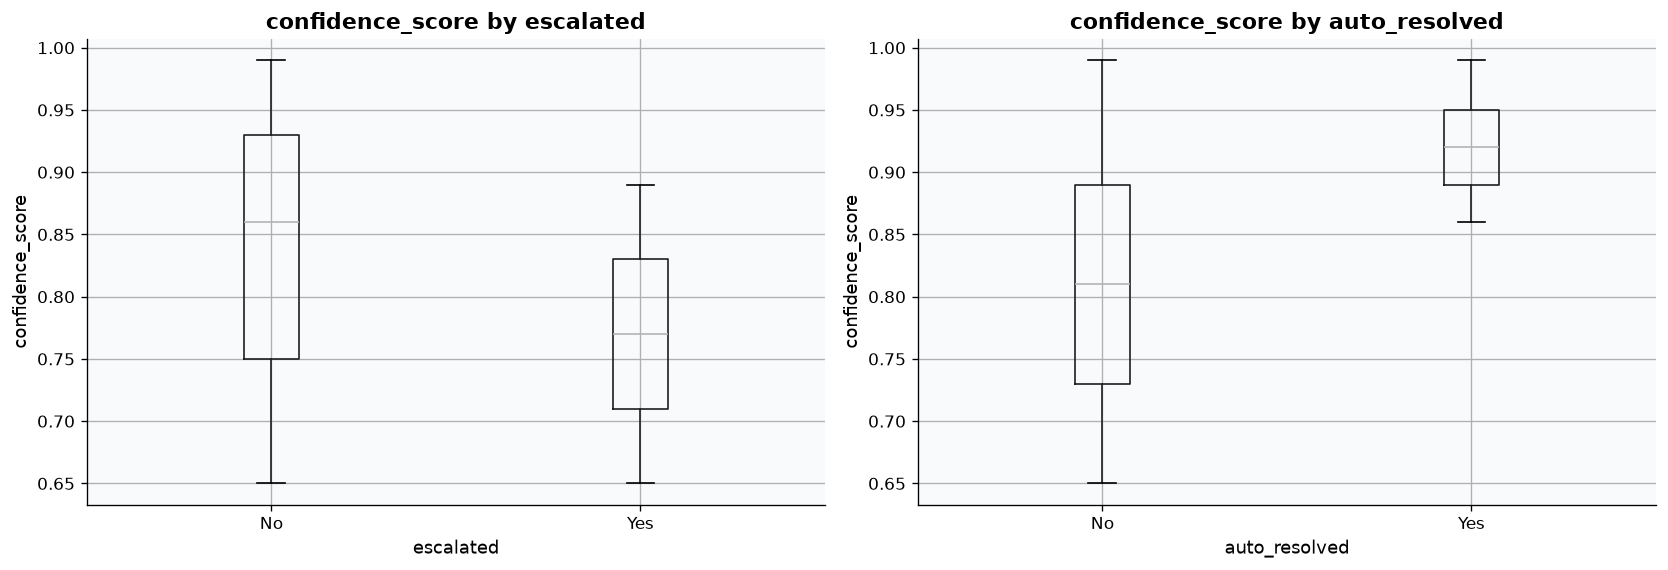

confidence_score summary stats by escalated:


,count,mean,std,min,25%,50%,75%,max
escalated,,,,,,,,
No,6622.0,0.842,0.102,0.65,0.75,0.86,0.93,0.99
Yes,3378.0,0.772,0.071,0.65,0.71,0.77,0.83,0.89



confidence_score summary stats by auto_resolved:


,count,mean,std,min,25%,50%,75%,max
auto_resolved,,,,,,,,
No,9304.0,0.810,0.097,0.65,0.73,0.81,0.89,0.99
Yes,696.0,0.922,0.038,0.86,0.89,0.92,0.95,0.99



Best single-threshold split on confidence_score (predict escalate if below threshold):
Threshold=0.67, accuracy against actual escalated=0.662


In [ ]:
section("confidence_score vs escalated / auto_resolved")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tickets_df.boxplot(column='confidence_score', by='escalated', ax=axes[0])
axes[0].set_title('confidence_score by escalated')
axes[0].set_xlabel('escalated')
axes[0].set_ylabel('confidence_score')

tickets_df.boxplot(column='confidence_score', by='auto_resolved', ax=axes[1])
axes[1].set_title('confidence_score by auto_resolved')
axes[1].set_xlabel('auto_resolved')
axes[1].set_ylabel('confidence_score')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("confidence_score summary stats by escalated:")
display(tickets_df.groupby('escalated')['confidence_score'].describe().round(3))

print("\nconfidence_score summary stats by auto_resolved:")
display(tickets_df.groupby('auto_resolved')['confidence_score'].describe().round(3))

# Find the threshold that best separates escalated vs not, using a simple sweep
import numpy as np
best_thresh, best_acc = None, 0
for t in np.arange(0.65, 0.99, 0.01):
    pred_escalate = tickets_df['confidence_score'] < t
    actual_escalate = tickets_df['escalated'] == 'Yes'
    acc = (pred_escalate == actual_escalate).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

print(f"\nBest single-threshold split on confidence_score (predict escalate if below threshold):")
print(f"Threshold={best_thresh:.2f}, accuracy against actual escalated={best_acc:.3f}")

#### frequent terms per category

In [16]:
section("Frequent Terms per Category")

import re
from collections import Counter

# Basic stopword list — enough for a quick distinctiveness check, not a full NLP pipeline
STOPWORDS = set("""
the a an and or but is are was were be been being to of in on at for with
this that these those i you he she it we they my your his her its our their
have has had do does did not no so as if then than too very can will would
could should just my me him them but received order item items my account ord
""".split())

def top_terms(text_series, n=15):
    words = []
    for t in text_series.dropna():
        tokens = re.findall(r"[a-zA-Z']+", t.lower())
        words.extend(w for w in tokens if w not in STOPWORDS and len(w) > 2)
    return Counter(words).most_common(n)

categories = tickets_df['ticket_category'].unique()
top_terms_per_cat = {}

for cat in categories:
    subset = tickets_df.loc[tickets_df['ticket_category'] == cat, 'ticket_text']
    top_terms_per_cat[cat] = top_terms(subset)
    print(f"--- {cat} ({len(subset)} tickets) ---")
    print(", ".join(f"{w}({c})" for w, c in top_terms_per_cat[cat]))
    print()

# Overlap check: how many of each category's top-15 terms also appear in another category's top-15?
print("=== Cross-category overlap in top-15 terms ===")
term_sets = {cat: set(w for w, _ in terms) for cat, terms in top_terms_per_cat.items()}
for cat, terms in term_sets.items():
    overlaps = {other: len(terms & other_terms) for other, other_terms in term_sets.items() if other != cat}
    worst = max(overlaps, key=overlaps.get)
    print(f"{cat}: most overlap with '{worst}' ({overlaps[worst]}/15 shared terms)")


  Frequent Terms per Category
--- Product Issue (1948 tickets) ---
from(544), product(363), completely(312), within(218), color(213), what(213), shown(213), battery(207), appears(200), box(195), like(194), used(194), warranty(192), stopped(187), after(187)

--- Refund & Return (2051 tickets) ---
return(1303), refund(1079), please(308), without(302), days(300), duplicate(227), defect(218), window(217), wrong(217), rejected(207), after(207), payment(206), exchange(204), returned(203), credited(197)

--- Payment Issue (1474 tickets) ---
payment(391), checkout(386), shows(310), deducted(242), balance(238), card(234), charged(228), now(215), amount(202), buy(176), code(162), err(162), pending(153), failed(153), option(152)

--- Seller & Product Listing (830 tickets) ---
seller(560), days(183), ordered(179), bought(150), listing(150), price(101), changed(101), after(101), placed(101), acceptable(101), responding(95), messages(95), past(95), bulk(91), fulfilled(91)

--- App & Website Issue (


  customer_satisfaction_score vs auto_resolved


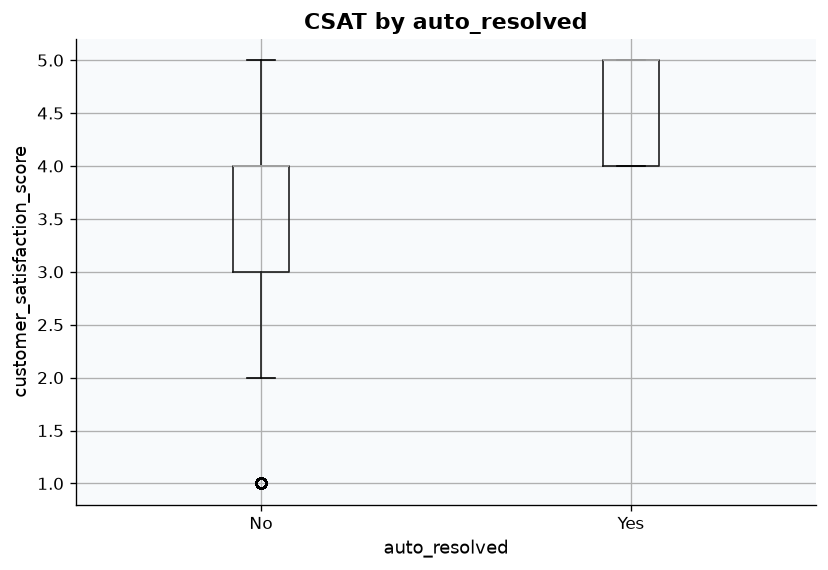

CSAT summary stats by auto_resolved:


,count,mean,std,min,25%,50%,75%,max
auto_resolved,,,,,,,,
No,9304.0,3.317,1.268,1.0,3.0,4.0,4.0,5.0
Yes,696.0,4.506,0.500,4.0,4.0,5.0,5.0,5.0



CSAT distribution among the 696 auto-resolved tickets:
customer_satisfaction_score
4    344
5    352
Name: count, dtype: int64

% of auto-resolved tickets meeting CSAT threshold:
CSAT >= 3: 100.0% (696 tickets)
CSAT >= 4: 100.0% (696 tickets)
CSAT >= 4.5: 50.6% (352 tickets)


In [17]:
section("customer_satisfaction_score vs auto_resolved")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
tickets_df.boxplot(column='customer_satisfaction_score', by='auto_resolved', ax=ax)
ax.set_title('CSAT by auto_resolved')
ax.set_xlabel('auto_resolved')
ax.set_ylabel('customer_satisfaction_score')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("CSAT summary stats by auto_resolved:")
display(tickets_df.groupby('auto_resolved')['customer_satisfaction_score'].describe().round(3))

# Distribution of CSAT scores specifically within auto_resolved tickets —
# this defines what "good example" means for the Learning agent
auto = tickets_df[tickets_df['auto_resolved'] == 'Yes']
print(f"\nCSAT distribution among the {len(auto)} auto-resolved tickets:")
print(auto['customer_satisfaction_score'].value_counts().sort_index())

# Candidate thresholds for "good example" — what % of auto-resolved tickets
# would qualify as high-CSAT "good examples" for the Learning agent at each cutoff?
print("\n% of auto-resolved tickets meeting CSAT threshold:")
for t in [3, 4, 4.5]:
    pct = (auto['customer_satisfaction_score'] >= t).mean()
    print(f"CSAT >= {t}: {pct:.1%} ({(auto['customer_satisfaction_score'] >= t).sum()} tickets)")

# Phase 2 Summary — EDA (Simple Version)

## 1. How the data is spread out
- **Category**: Refund & Return is the biggest group (about 1 in 5 tickets). App & Website Issue is the smallest. Not too imbalanced.
- **Priority**: High is actually the most common priority (46%), not the rare one. So a model that just guesses "High" every time would already be right almost half the time — we need to make sure our real model beats that.
- **Sentiment**: Most tickets lean negative, which makes sense for support tickets. Positive is the rarest feeling.

## 2. Does an angry customer always get escalated?
- If sentiment is Neutral, Positive, or Slightly Negative — the ticket **never** escalates. Not rare, never, in every category.
- If sentiment is Negative or Very Negative — it escalates about 73% of the time, pretty consistently.
- Category almost doesn't matter on top of sentiment, except one case: **Account & Login** tickets escalate less often even when the customer is angry. We checked this with a proper statistical test, and it's real, not random noise.

## 3. Does confidence_score predict anything?
- It's a weak predictor of escalation.
- But it's a strong predictor of auto-resolution — once the score goes above about 0.85, the ticket tends to get auto-resolved. This is probably the actual rule used to generate this data.

## 4. Do categories use different words?
- At first it looked like every category shared one weird word: "ord." Turns out that was a bug — order numbers like #ORD5614226 were getting cut in half by our word-splitting code.
- After fixing that, each category clearly has its own vocabulary (payment tickets say "charged," delivery tickets say "tracking," etc.).
- This means a simple word-based model (TF-IDF) would actually work okay here. But we're still using AI sentence embeddings as our main method, because real customers phrase things differently ("stopped charging" instead of "battery"), and only embeddings can catch that. We're keeping the simple method too, just to prove the fancier one is actually worth it.

## 5. Does auto-resolving make customers happy?
- Every single auto-resolved ticket has a satisfaction score of 4 or 5 — no exceptions.
- This actually removes a filtering step we planned earlier ("pick out the high-satisfaction auto-resolved tickets") — there's nothing to filter, they're all already high satisfaction.

## 6. How often do tickets actually escalate?
- The `escalated` column shows **33.8%** of tickets (3,378 of 10,000) are escalated 

## Status
EDA is done. Every finding above led to a real decision about how the agents will be built — nothing here was just a chart for the sake of it.